# 📊 Amazon Electronics Products - Exploratory Data Analysis

**Dataset:** 348,228 Electronics Products  
**Database:** PostgreSQL (amazon_electronics_rag)  
**Date:** October 29, 2025

---

## Setup & Imports

In [2]:
# Install required packages (run this cell first, then restart kernel)
import sys
!{sys.executable} -m pip install wordcloud plotly scipy kaleido -q
print("✅ Packages installed! Please restart the kernel: Kernel → Restart Kernel")

✅ Packages installed! Please restart the kernel: Kernel → Restart Kernel


In [3]:
# Core libraries
import pandas as pd
import numpy as np
import psycopg2
import json
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Text analysis
from wordcloud import WordCloud
from collections import Counter
import re

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports complete!")

✅ Imports complete!


## Database Connection

In [4]:
# Connect to PostgreSQL
def get_connection():
    return psycopg2.connect(
        dbname="amazon_electronics_rag",
        user="shivamsharma",
        host="localhost",
        port="5432"
    )

# Test connection
conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM products;")
total_products = cur.fetchone()[0]
cur.close()
conn.close()

print(f"✅ Connected to database")
print(f"📦 Total products: {total_products:,}")

✅ Connected to database
📦 Total products: 348,228


---

# Phase 1: Basic Dataset Overview

## 1.1 Load Data

In [5]:
# Load full dataset
query = """
SELECT 
    parent_asin,
    title,
    description,
    features,
    price,
    average_rating,
    rating_number,
    main_category,
    store,
    images,
    videos,
    CASE WHEN blair_embedding IS NOT NULL THEN TRUE ELSE FALSE END as has_embedding,
    created_at
FROM products;
"""

print("Loading data from PostgreSQL...")
df = pd.read_sql_query(query, get_connection())
print(f"✅ Loaded {len(df):,} products")
df.head()

Loading data from PostgreSQL...


/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_51392/1627643899.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, get_connection())


✅ Loaded 348,228 products


,parent_asin,title,description,features,price,average_rating,rating_number,main_category,store,images,videos,has_embedding,created_at
0,B018JN8B9G,Novpeak 16G CZ Gem Clear Crystal Stainless Ste...,None,None,NaN,3.90,81,AMAZON FASHION,Novpeak,{'large': ['https://m.media-amazon.com/images/...,"{'url': [], 'title': [], 'user_id': []}",True,2025-10-07 03:11:30.132071
1,B018JO21BE,bestseller2016 10pcs SMA RF Coax Connector Mal...,Product Type:SMA RF coax connector Gender: mal...,"Type: SMA Coax connector Gender:male plug,stra...",7.99,3.70,43,Home Audio & Theater,bestseller2016,{'large': ['https://m.media-amazon.com/images/...,{'url': ['https://www.amazon.com/vdp/0ab6ec718...,True,2025-10-07 03:11:12.653001
2,B018JR10LS,Silver Edition 15.5 x 21mm [704] c,None,None,NaN,4.70,27,Computers,VATH,{'large': ['https://m.media-amazon.com/images/...,"{'url': [], 'title': [], 'user_id': []}",True,2025-10-07 03:10:40.888197
3,B018JR74S6,iON Camera SnapCam Wearable HD Camera with Wi-...,"The ion snapcam wearable, shareable HD camera ...",1 hour live broadcasting 8MP image sensor Hd 7...,NaN,2.60,53,Camera & Photo,iON Camera,{'large': ['https://m.media-amazon.com/images/...,{'url': ['https://www.amazon.com/vdp/e977e61a6...,True,2025-10-07 03:11:49.185691
4,B018JRPLUY,JETech Bluetooth Keyboard Case for iPad Pro 12...,None,Designed for iPad Pro 12.9 (2015 Model ONLY). ...,NaN,3.80,438,Computers,JETech,{'large': ['https://m.media-amazon.com/images/...,"{'url': [], 'title': [], 'user_id': []}",True,2025-10-07 03:10:47.145869


## 1.2 Dataset Info

In [6]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
df.describe()

DATASET OVERVIEW
Rows: 348,228
Columns: 13

Memory Usage: 866.14 MB

Column Types:
parent_asin               object
title                     object
description               object
features                  object
price                    float64
average_rating           float64
rating_number              int64
main_category             object
store                     object
images                    object
videos                    object
has_embedding               bool
created_at        datetime64[ns]
dtype: object

Basic Statistics:


,price,average_rating,rating_number,created_at
count,153542.00,348228.00,348228.00,348228
mean,84.99,4.08,614.03,2025-10-07 03:11:32.241286144
min,0.01,1.00,1.00,2025-10-07 03:10:21.087967
25%,12.99,3.80,37.00,2025-10-07 03:10:57.177792
50%,24.99,4.20,98.00,2025-10-07 03:11:30.132070912
75%,67.99,4.40,301.00,2025-10-07 03:12:10.690167040
max,24996.99,5.00,1034896.00,2025-10-07 03:12:50.453330
std,233.96,0.47,5032.01,NaN


## 1.3 Missing Data

MISSING DATA ANALYSIS
        Column  Missing Count  Missing %
         price         194686      55.91
   description         153279      44.02
      features          55773      16.02
 main_category           6503       1.87
         store            859       0.25
   parent_asin              0       0.00
         title              0       0.00
average_rating              0       0.00
 rating_number              0       0.00
        images              0       0.00
        videos              0       0.00
 has_embedding              0       0.00
    created_at              0       0.00


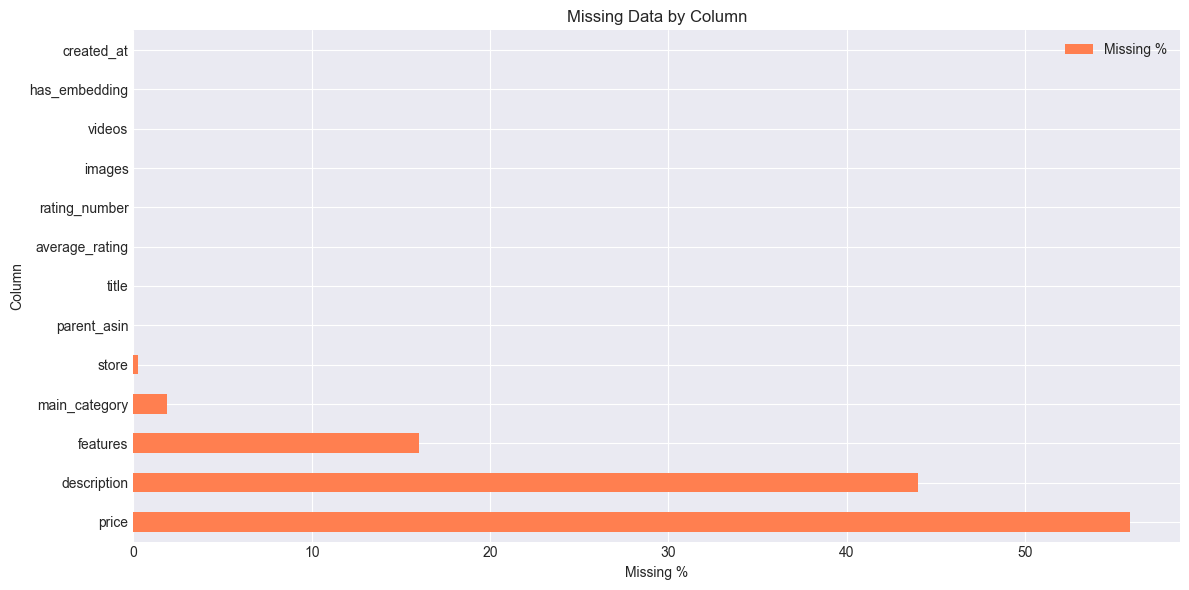

In [7]:
# Missing data analysis
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print("="*80)
print("MISSING DATA ANALYSIS")
print("="*80)
print(missing_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
missing_df.plot(x='Column', y='Missing %', kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing %')
ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.show()

---

# Phase 2: Category Analysis

## 2.1 Main Category Distribution

TOP 30 CATEGORIES
 1. All Electronics                       94,856 (27.24%)
 2. Computers                             92,640 (26.60%)
 3. Camera & Photo                        49,703 (14.27%)
 4. Cell Phones & Accessories             30,989 ( 8.90%)
 5. Home Audio & Theater                  26,249 ( 7.54%)
 6. Industrial & Scientific               11,025 ( 3.17%)
 7. Car Electronics                        5,752 ( 1.65%)
 8. Tools & Home Improvement               5,026 ( 1.44%)
 9. Office Products                        4,511 ( 1.30%)
10. Amazon Home                            3,179 ( 0.91%)
11. Amazon Devices                         3,174 ( 0.91%)
12. Sports & Outdoors                      2,674 ( 0.77%)
13. AMAZON FASHION                         2,568 ( 0.74%)
14. Automotive                             2,419 ( 0.69%)
15. Musical Instruments                    1,878 ( 0.54%)
16. GPS & Navigation                       1,142 ( 0.33%)
17. Portable Audio & Accessories             898 ( 0.2

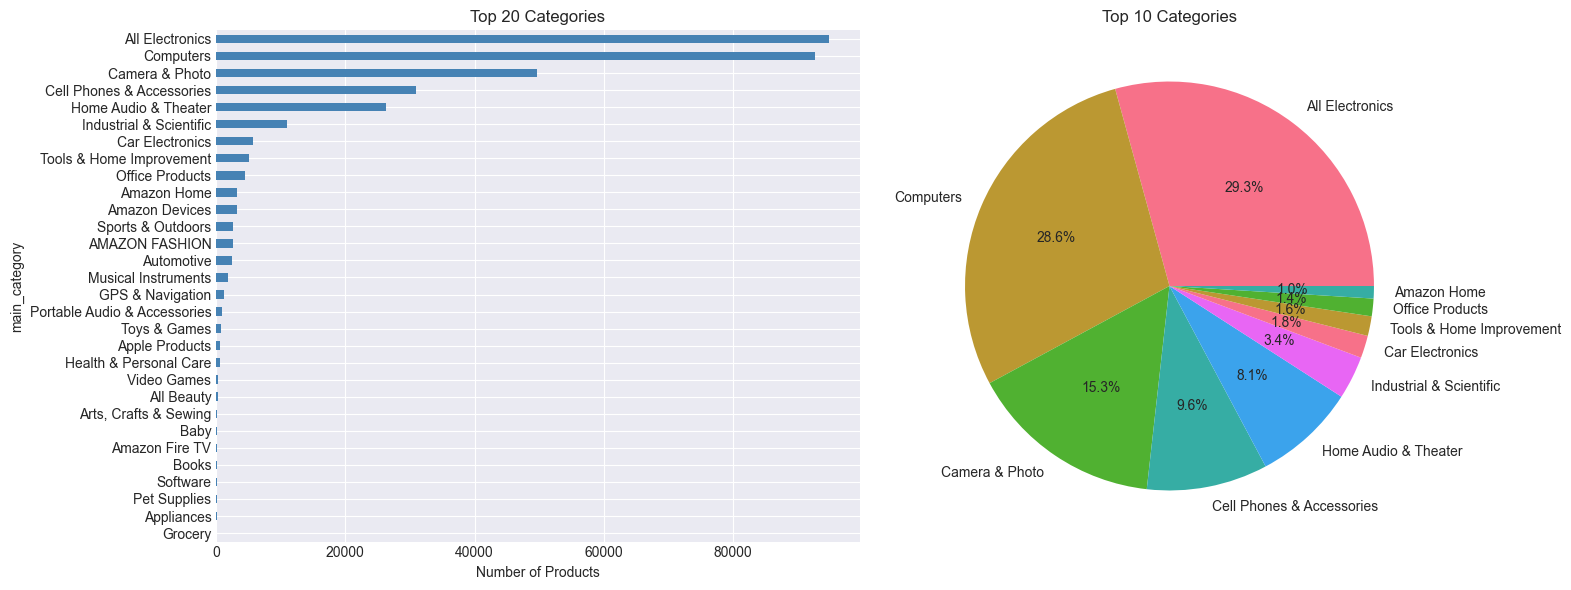

In [8]:
# Top 20 categories
category_counts = df['main_category'].value_counts().head(30)

print("="*80)
print("TOP 30 CATEGORIES")
print("="*80)
for i, (cat, count) in enumerate(category_counts.items(), 1):
    pct = count / len(df) * 100
    print(f"{i:2}. {cat:35} {count:8,} ({pct:5.2f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

category_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Products')
ax1.set_title('Top 20 Categories')
ax1.invert_yaxis()

category_counts.head(10).plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_ylabel('')
ax2.set_title('Top 10 Categories')

plt.tight_layout()
plt.show()

---

# Phase 3: Price Analysis

## 3.1 Price Distribution

PRICE STATISTICS
Products with price: 153,542 (44.1%)

Statistics:
count   153542.00
mean        84.99
std        233.96
min          0.01
25%         12.99
50%         24.99
75%         67.99
max      24996.99
Name: price, dtype: float64


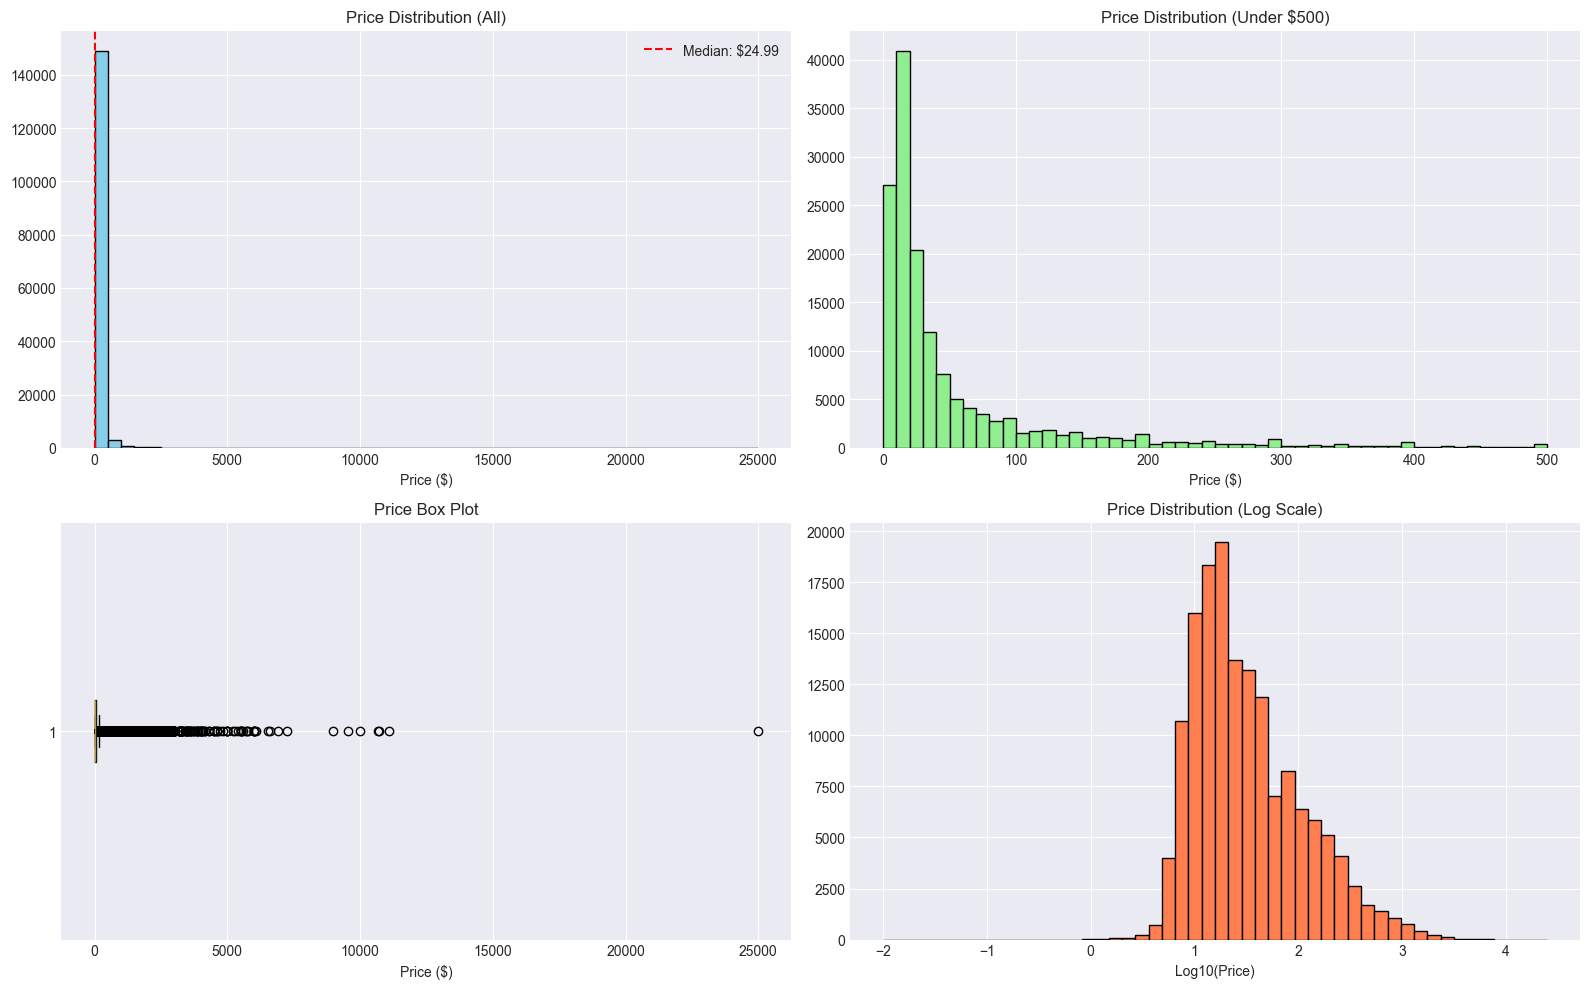

In [9]:
# Price statistics
price_data = df[df['price'].notna()]['price']

print("="*80)
print("PRICE STATISTICS")
print("="*80)
print(f"Products with price: {len(price_data):,} ({len(price_data)/len(df)*100:.1f}%)")
print(f"\nStatistics:")
print(price_data.describe())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# All prices
axes[0,0].hist(price_data, bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_title('Price Distribution (All)')
axes[0,0].axvline(price_data.median(), color='red', linestyle='--', label=f'Median: ${price_data.median():.2f}')
axes[0,0].legend()

# Under $500
price_under_500 = price_data[price_data <= 500]
axes[0,1].hist(price_under_500, bins=50, color='lightgreen', edgecolor='black')
axes[0,1].set_xlabel('Price ($)')
axes[0,1].set_title('Price Distribution (Under $500)')

# Box plot
axes[1,0].boxplot(price_data, vert=False)
axes[1,0].set_xlabel('Price ($)')
axes[1,0].set_title('Price Box Plot')

# Log scale
axes[1,1].hist(np.log10(price_data[price_data > 0]), bins=50, color='coral', edgecolor='black')
axes[1,1].set_xlabel('Log10(Price)')
axes[1,1].set_title('Price Distribution (Log Scale)')

plt.tight_layout()
plt.show()

---

# Phase 4: Rating Analysis

## 4.1 Rating Distribution

RATING STATISTICS
Products with ratings: 348,228 (100.0%)

Statistics:
count   348228.00
mean         4.08
std          0.47
min          1.00
25%          3.80
50%          4.20
75%          4.40
max          5.00
Name: average_rating, dtype: float64


/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_51392/1554857941.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


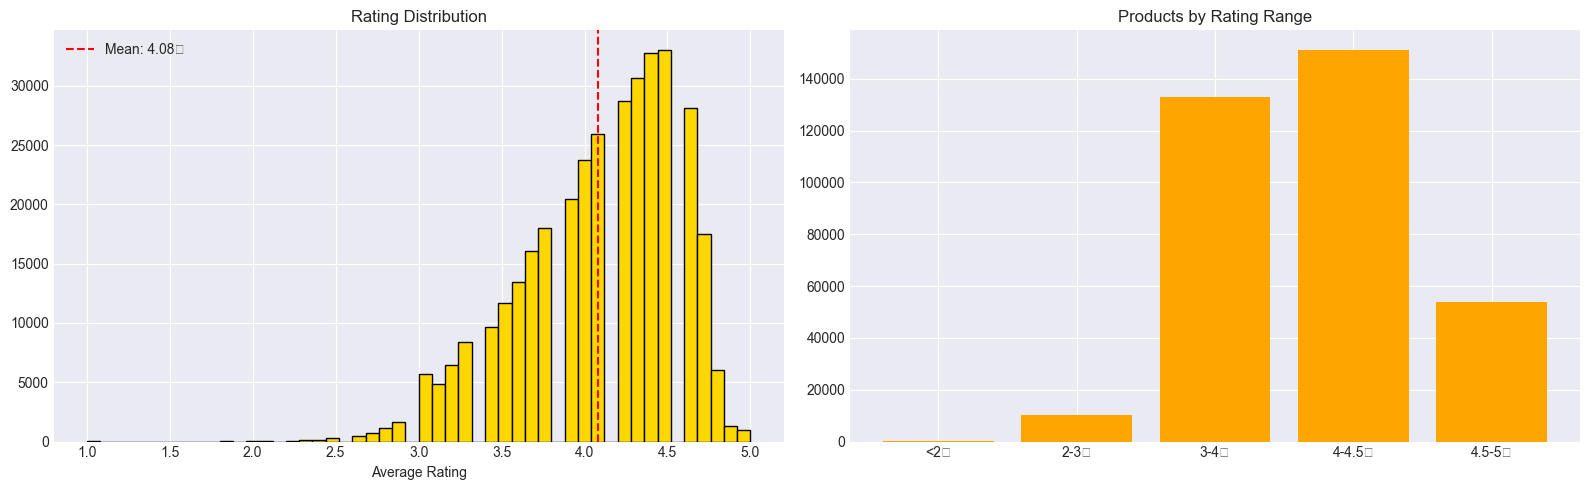

In [10]:
# Rating statistics
rating_data = df[df['average_rating'].notna()]['average_rating']

print("="*80)
print("RATING STATISTICS")
print("="*80)
print(f"Products with ratings: {len(rating_data):,} ({len(rating_data)/len(df)*100:.1f}%)")
print(f"\nStatistics:")
print(rating_data.describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(rating_data, bins=50, color='gold', edgecolor='black')
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Rating Distribution')
axes[0].axvline(rating_data.mean(), color='red', linestyle='--', label=f'Mean: {rating_data.mean():.2f}★')
axes[0].legend()

rating_bins = pd.cut(rating_data, bins=[0, 2, 3, 4, 4.5, 5], labels=['<2★', '2-3★', '3-4★', '4-4.5★', '4.5-5★'])
rating_bin_counts = rating_bins.value_counts().sort_index()
axes[1].bar(range(len(rating_bin_counts)), rating_bin_counts.values, color='orange')
axes[1].set_xticks(range(len(rating_bin_counts)))
axes[1].set_xticklabels(rating_bin_counts.index)
axes[1].set_title('Products by Rating Range')

plt.tight_layout()
plt.show()

---

# Phase 5: Text Analysis

## 5.1 Title Analysis

TITLE ANALYSIS
Average title length: 124.5 characters
Median: 124.0

Top 50 Words in Titles:
 1. with                  142,910
 2. case                   63,746
 3. black                  60,609
 4. cable                  53,230
 5. inch                   45,152
 6. camera                 43,300
 7. ipad                   38,450
 8. compatible             37,793
 9. adapter                36,830
10. laptop                 34,438
11. wireless               30,452
12. cover                  27,360
13. power                  27,093
14. bluetooth              25,916
15. pack                   25,237
16. mini                   23,539
17. battery                22,703
18. hdmi                   22,603
19. stand                  22,117
20. screen                 20,865
21. audio                  20,183
22. mount                  20,059
23. charger                19,858
24. tablet                 18,778
25. digital                18,746
26. samsung                18,197
27. replacement        

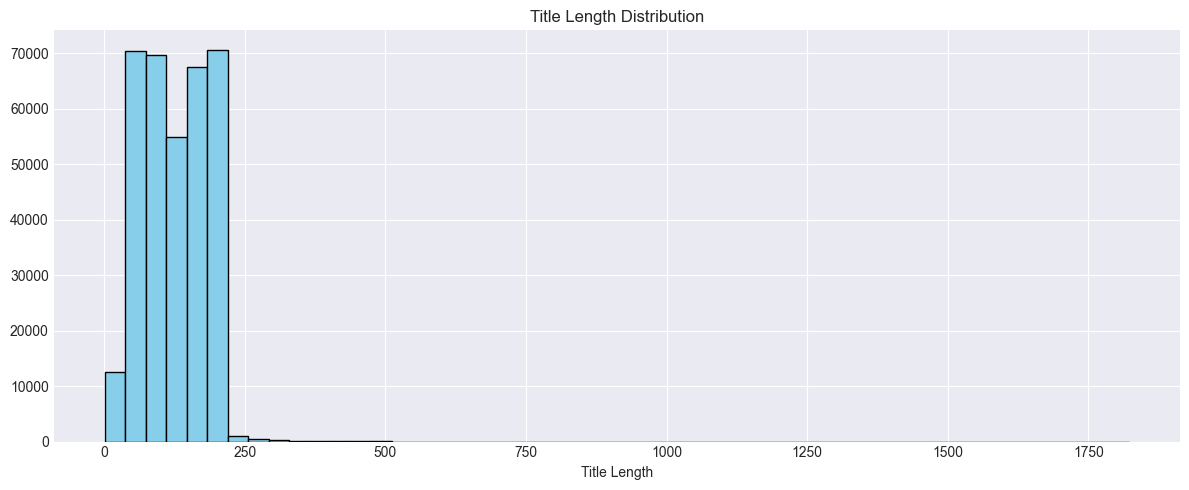

In [11]:
# Title lengths
df['title_length'] = df['title'].str.len()

print("="*80)
print("TITLE ANALYSIS")
print("="*80)
print(f"Average title length: {df['title_length'].mean():.1f} characters")
print(f"Median: {df['title_length'].median():.1f}")

# Most common words
all_titles = ' '.join(df['title'].dropna().astype(str))
words = re.findall(r'\b\w{4,}\b', all_titles.lower())
word_counts = Counter(words).most_common(50)

print("\nTop 50 Words in Titles:")
for i, (word, count) in enumerate(word_counts, 1):
    print(f"{i:2}. {word:20} {count:8,}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
df['title_length'].hist(bins=50, ax=ax, color='skyblue', edgecolor='black')
ax.set_xlabel('Title Length')
ax.set_title('Title Length Distribution')
plt.tight_layout()
plt.show()

---

# Phase 6: Correlations

## 6.1 Price vs Rating

PRICE vs RATING
Pearson correlation: -0.0496
Sample size: 153,542


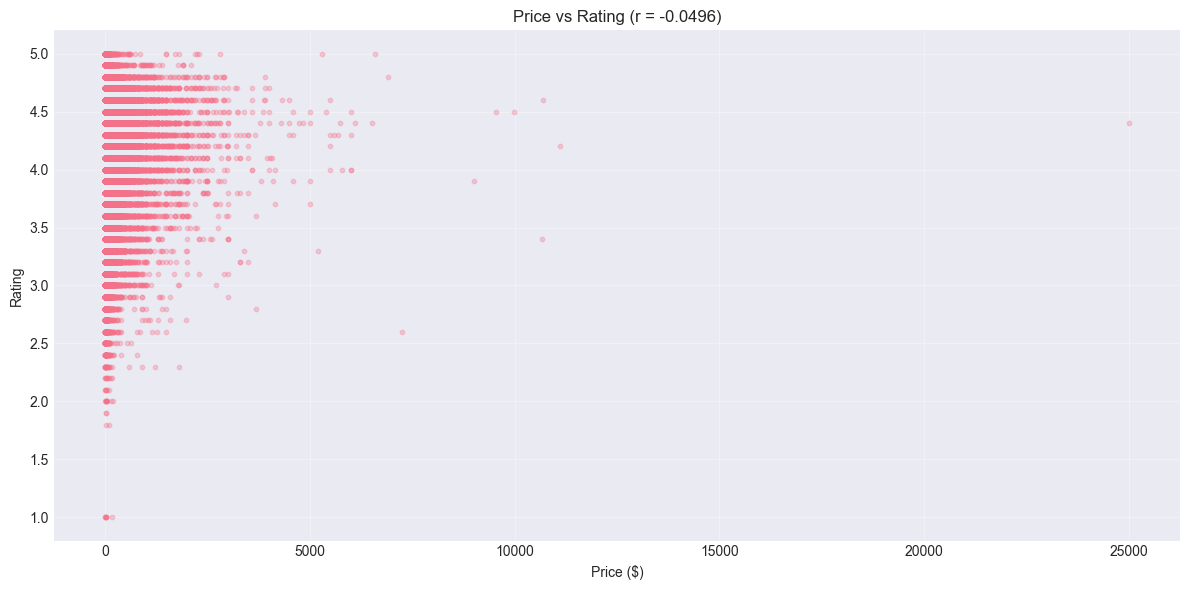

In [12]:
# Price vs Rating correlation
price_rating_df = df[(df['price'].notna()) & (df['average_rating'].notna())].copy()

pearson_corr, _ = pearsonr(price_rating_df['price'], price_rating_df['average_rating'])

print("="*80)
print("PRICE vs RATING")
print("="*80)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Sample size: {len(price_rating_df):,}")

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(price_rating_df['price'], price_rating_df['average_rating'], alpha=0.3, s=10)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Rating')
ax.set_title(f'Price vs Rating (r = {pearson_corr:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Summary

In [13]:
# Export summary
summary = {
    'Total Products': len(df),
    'Unique Categories': df['main_category'].nunique(),
    'Products with Price': df['price'].notna().sum(),
    'Avg Price': df['price'].mean(),
    'Products with Rating': df['average_rating'].notna().sum(),
    'Avg Rating': df['average_rating'].mean(),
    'Products with Embeddings': df['has_embedding'].sum()
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('products_eda_summary.csv', index=False)

print("="*80)
print("EDA COMPLETE!")
print("="*80)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value:,}")

EDA COMPLETE!
Total Products: 348,228
Unique Categories: 38
Products with Price: 153,542
Avg Price: 84.99
Products with Rating: 348,228
Avg Rating: 4.08
Products with Embeddings: 348,228
